# MMC Chatbot — MEAL Satisfaction Analysis

Satisfaction descriptives over the **78 MEAL responses**: how useful the service
was, whether people would recommend it, and how they found it. Companion to
`analysis_responses.ipynb`.

> **Technical note — small sample.** 78 responses. Every proportion is
> directional; read counts alongside percentages.

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from palette import *
import mmc_data
meal = mmc_data.load_meal()
print(f"{len(meal)} MEAL responses")

78 MEAL responses


## 1. Utility rating

**What this shows.** How useful respondents found the service, on a 4-point
Spanish scale from *Nada útil* to *Muy útil*. **Why it matters.** It's the
single closest proxy we have to overall service quality as perceived by users.

> **Technical note — small sample.** With 78 responses, treat the percentages
> below as directional signal, not precise estimates.

utility
Nada útil            17.6
Medianamente útil    13.5
Útil                 20.3
Muy útil             48.6
Name: count, dtype: float64


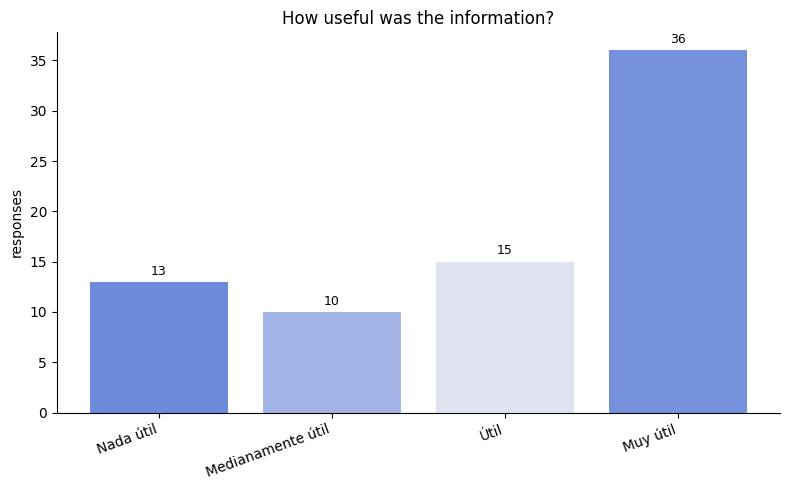

In [2]:
UTIL_ORDER = ["Nada útil", "Medianamente útil", "Útil", "Muy útil"]
u = meal["utility"].value_counts().reindex(UTIL_ORDER).fillna(0)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(u.index, u.values, color=bar_colors(len(u)))
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("How useful was the information?")
ax.set_ylabel("responses")
ax.set_xticklabels(u.index, rotation=20, ha="right")
plt.tight_layout()
print((u / u.sum() * 100).round(1))

## 2. Would-recommend

**What this shows.** Whether respondents would recommend the service to
others. **Why it matters.** Willingness to recommend is a stronger signal
than a rating alone — it implies the respondent believes the service would
help someone else too.

would_recommend
Sí                       79.5
Prefiero no responder    19.2
No                        1.3
Name: count, dtype: float64


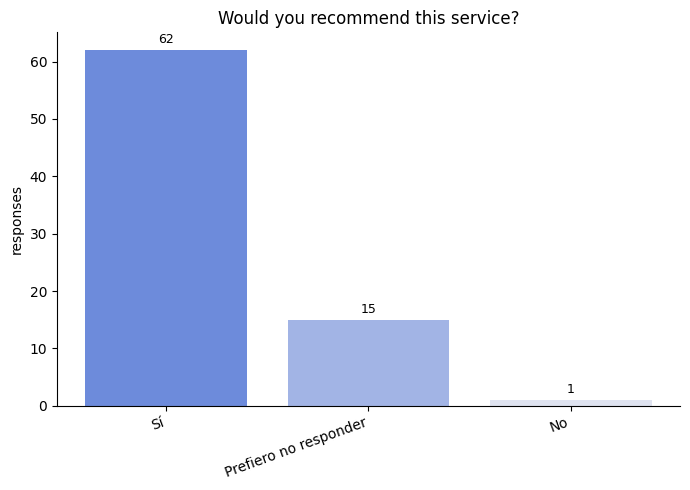

In [3]:
r = meal["would_recommend"].value_counts()
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(r.index, r.values, color=bar_colors(len(r)))
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Would you recommend this service?")
ax.set_ylabel("responses")
ax.set_xticklabels(r.index, rotation=20, ha="right")
plt.tight_layout()
print((r / r.sum() * 100).round(1))

## 3. How they heard (channel + medium)

**What this shows.** The channel respondents used to first learn about the
service (`heard_channel`), plus a free-text breakdown of the specific medium
where "other" was selected (`heard_medium`). **Why it matters.** It tells MMC
which outreach channels are actually driving adoption, so promotion effort
can be concentrated there.

> **Technical note.** `heard_medium` is a free-text follow-up field, so its
> value counts are necessarily small and fragmented — read it as illustrative
> detail, not a ranked channel list.

free-text 'other' media:
heard_medium
Redes sociales                   1
Otro                             1
Ayudas inmigrantes en ipiales    1
Inteligencia artificial          1
Intégrate                        1
Por el medio de intégrate        1
wrwr                             1
Me lo recomendaron               1
Internet                         1
X un amigo                       1
Name: count, dtype: int64


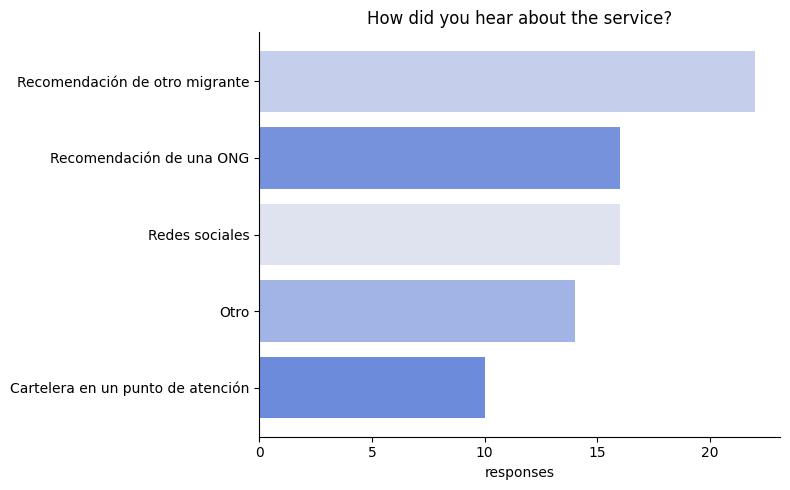

In [4]:
h = meal["heard_channel"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
order = h.iloc[::-1]
ax.barh(order.index, order.values, color=bar_colors(len(order)))
ax.set_title("How did you hear about the service?")
ax.set_xlabel("responses")
plt.tight_layout()
print("free-text 'other' media:")
print(meal["heard_medium"].dropna().value_counts().head(10))

## 4. Free-text recommendations (thematic read)

**What this shows.** What respondents wrote when asked what could be
improved, after filtering out non-answers (e.g. "no", "ninguna"). **Why it
matters.** Free text is the only place respondents can raise something the
closed-ended questions didn't anticipate.

> **Technical note — qualitative only.** With 78 rows and a majority of blank
> or "no" answers, the remaining free text is read manually below rather than
> topic-modeled or embedded — there isn't enough volume for that to be
> meaningful. This is a qualitative pass, not a quantitative one.

In [5]:
recs = meal["recommendation"].dropna().astype(str)
recs = recs[~recs.str.strip().str.lower().isin(["no", "ninguna", "ninguno", "nada"])]
print(f"{len(recs)} substantive recommendations\n")
for t in recs.head(20):
    print("•", t)

42 substantive recommendations

• Excelente
• Ayuda, no se cómo activar mi línea nueva Tigo y mi internet
• No recibí ninguna información.
• No recibí información
• Todo bien gracias 😌🫂
• Ayudas en Bucaramanga
• Me necesito hablo con persona ! Esto es urgencia !!!!
• Será que hay un punto de atención para los migrante vía cali
• Que respondan todas las dudas
• Actualizar la dirección de Migración Colombia en Cúcuta
• Ayuda humanitaria
• Q dan informaciónes buenas
• Llegue al punto a la una de la tarde y estaba cerrado el punto de atencion en la terminal del norte. Favor no cerrar los puntos
• Poder responder a la pregunta hecha cuando cambia el tema
• necesito saber la dirección de un refugio en cali
• Si , actualizar la información
• Todo esta perfecto
• Perfecto
• El servicio es muy excelente
• No por el momento
